# ARTI403 — Image Processing
## Lab 2 — Digital Image Fundamentals

**Session 2 · Digital Image Fundamentals**
Sampling, quantization, arithmetic operations, and set/logical operations on digital images using OpenCV, Pillow, NumPy, and Matplotlib.

| | |
|---|---|
| **Duration** | 100 minutes |
| **Outcome** | Explain how digital images are represented and manipulated in a computer |
| **Tools** | Python 3, Anaconda (Jupyter / Spyder); Libraries: OpenCV, Pillow |

---

### How to work through the notebook

* The lab has three parts — **Image Sampling and Quantization**, **Arithmetic Operations**, and **Sets and Logical Operations** — each followed by its required Task(s).
* Run the cells **in order**, top to bottom. Part 2 defines `img1`/`img2`; Part 3 defines its own `img3`/`img4` and does not need Part 2's variables.
* All three parts need image files that are **not included** in this notebook — see the note right below for exactly where to place them.
* The **Assessment** is at the end of the notebook.

---

### By the end of this lab you should be able to

1. Downsample and quantize an image, and explain how each parameter changes its appearance.
2. Perform arithmetic operations (addition, subtraction, adding a constant) on images as NumPy arrays.
3. Correctly handle `uint8` overflow so arithmetic results are not corrupted.
4. Perform set/logical operations (union, intersection, difference, symmetric difference) on grayscale images.

> **Before running the cells below:** create a folder named `images` **one level above** this notebook's folder (i.e. `../images/`, matching the paths used throughout this lab), and place these four files inside it:
> * `images/lena_gray_256.tif`
> * `images/cameraman.tif`
> * `images/A.png`
> * `images/B.png`
>
> `lena_gray_256.tif` and `cameraman.tif` are standard grayscale test images; `A.png` and `B.png` are the two shape images used in Part 3. Ask your instructor for them if you do not already have them from the course resources. If you would rather keep `images` next to the notebook instead, change the `../images/...` paths below to `images/...`.

---
## Setup

Run this cell first. It imports every library used in this lab and confirms they are installed.

In [30]:
# If a library below is missing, install it first (uncomment as needed):
#!pip install opencv-python pillow matplotlib numpy

import cv2
import numpy as np
import PIL
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt

print("OpenCV     :", cv2.__version__)
print("Pillow     :", PIL.__version__)
print("Matplotlib :", matplotlib.__version__)
print("NumPy      :", np.__version__)

print("\nSetup OK")

OpenCV     : 5.0.0
Pillow     : 12.3.0
Matplotlib : 3.11.2
NumPy      : 2.5.3

Setup OK


---
## Part 1 — Image Sampling and Quantization

This part downsamples an image (**sampling**) and reduces its number of gray levels (**quantization**), then compares both effects side by side with the original. `cv2`, `np`, and `plt` (Step #1 of the manual) were already imported in **Setup** above.

### Step #2 — Define the sampling, quantization, and plotting functions

`sample_image` downsamples an image by keeping only every `factor`-th pixel. `quantize_image` rounds every pixel down to the nearest of `levels` evenly spaced gray values. `plot_images` displays the three versions side by side.

In [31]:
def sample_image(image, factor):
    """
    Downsamples the image by the given factor.

    Args:
        image (numpy array): Original image.
        factor (int): Factor by which to downsample.

    Returns:
        numpy array: Downsampled image.
    """
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)
    return sampled_image


def quantize_image(image, levels):
    """
    Reduces the number of grayscale levels in the image.

    Args:
        image (numpy array): Original image.
        levels (int): Number of grayscale levels.

    Returns:
        numpy array: Quantized image.
    """
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image


def plot_images(original, sampled, quantized):
    """
    Plots the original, sampled, and quantized images side by side.

    Args:
        original (numpy array): Original image.
        sampled (numpy array): Sampled image.
        quantized (numpy array): Quantized image.
    """
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')
    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')
    plt.show()

### Step #3 — Load the image and run sampling + quantization

Load `lena_gray_256.tif` in grayscale, then sample it with `sampling_factor = 14` and quantize it with `quantization_levels = 9`, exactly as specified in the manual.

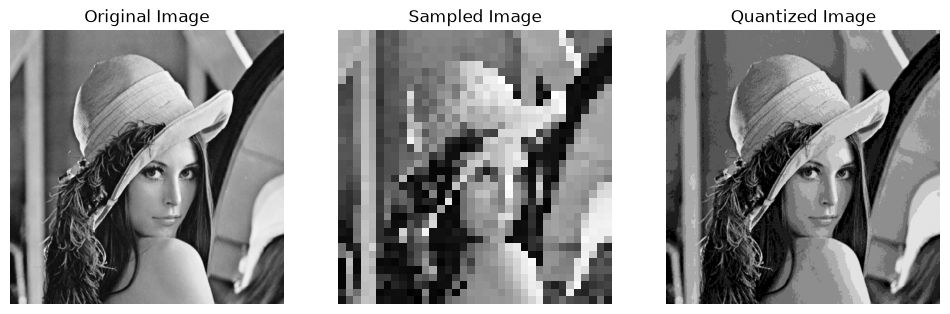

In [32]:
image_path = '../images/lena_gray_256.tif'
sampling_factor = 14
quantization_levels = 9

# Load image in grayscale
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if original_image is None:
    print(f"Error: Unable to load image at {image_path}")

# Sample and quantize
sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

# Plot results
plot_images(original_image, sampled_image, quantized_image)

---
### Task #1 — Change the parameters and observe the effects

Two more combinations of `sampling_factor` and `quantization_levels` — a mild change and a strong change — compared against the original settings above.

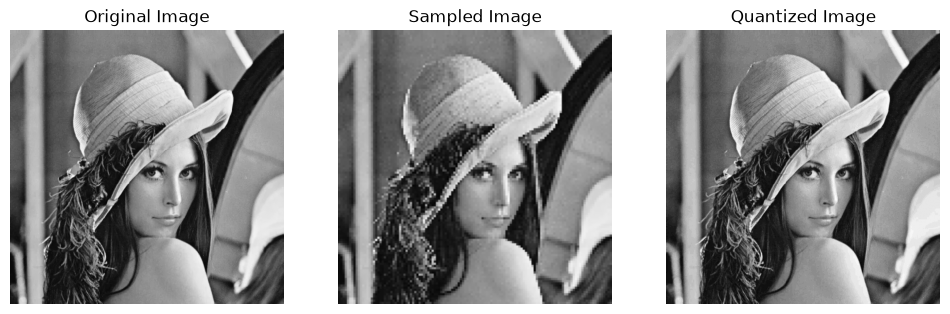

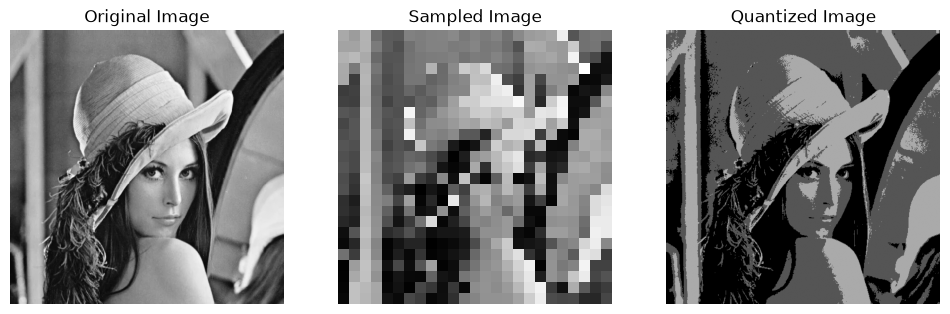

In [33]:
# A mild change: light sampling, many gray levels
sampled_mild = sample_image(original_image, factor=4)
quantized_mild = quantize_image(original_image, levels=32)
plot_images(original_image, sampled_mild, quantized_mild)

# A strong change: heavy sampling, very few gray levels
sampled_strong = sample_image(original_image, factor=20)
quantized_strong = quantize_image(original_image, levels=3)
plot_images(original_image, sampled_strong, quantized_strong)

**Observations:**
* **Sampling factor** controls spatial resolution: a larger factor keeps fewer pixels, so the sampled image looks blockier and more pixelated (`factor=20` loses far more detail than `factor=4`).
* **Quantization levels** control how many distinct gray shades are allowed: fewer levels create visible banding/posterization (`levels=3` looks almost like a poster compared to the smooth original, while `levels=32` is barely different from it).
* The two parameters are independent — one controls *how many pixels* are kept, the other controls *how many shades* each pixel can take.

---
## Part 2 — Arithmetic Operations

This part loads two images with PIL, resizes them to a common size, and performs arithmetic directly on their NumPy arrays.

### Load, resize, and convert to arrays

Both images are resized to `400 x 400` so their arrays line up element-for-element for the arithmetic below.

In [34]:
img1 = Image.open('../images/lena_gray_256.tif').convert('L')
img2 = Image.open('../images/cameraman.tif').convert('L')

resize = (400, 400)
img1 = img1.resize(resize, Image.Resampling.LANCZOS)
img2 = img2.resize(resize, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

print("im1arr:", im1arr.shape, im1arr.dtype)
print("im2arr:", im2arr.shape, im2arr.dtype)

im1arr: (400, 400) uint8
im2arr: (400, 400) uint8


### The manual's example: adding the two images

The manual adds the two arrays directly and wraps the result back into a PIL image for display.

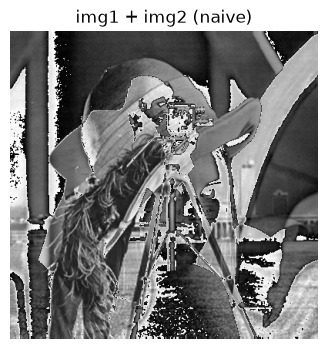

In [35]:
addition = im1arr + im2arr  # naive addition, exactly as given in the manual

plt.figure(figsize=(4, 4))
plt.imshow(addition, cmap='gray')
plt.title('img1 + img2 (naive)')
plt.axis('off')
plt.show()

**Why this is risky:** `im1arr` and `im2arr` are `uint8` arrays, so every value is stored in the range 0-255. When two pixels add up to more than 255 (e.g. `200 + 100 = 300`), a `uint8` array cannot hold `300` — it **wraps around** (`300 mod 256 = 44`) instead of saturating at white. That shows up as unexpectedly dark speckles in bright areas of the result above.

The tasks below fix this by casting to a wider type (`int16`) before the arithmetic, then clipping back to the valid `[0, 255]` range before converting back to `uint8`.

---
### Task #2 — Subtract two images, and add a constant to one image

Both operations below cast to `int16` first and `np.clip` the result to `[0, 255]` before converting back to `uint8`, so the result is correct instead of wrapped.

**1. Subtract two images**

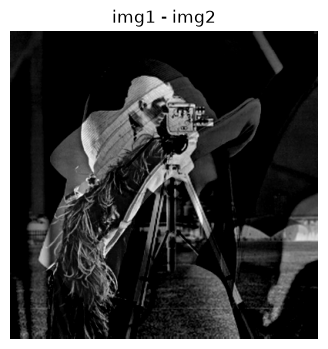

In [36]:
# Subtract img2 from img1, handling uint8 overflow correctly
subtraction = np.clip(im1arr.astype(np.int16) - im2arr.astype(np.int16), 0, 255).astype(np.uint8)

plt.figure(figsize=(4, 4))
plt.imshow(subtraction, cmap='gray')
plt.title('img1 - img2')
plt.axis('off')
plt.show()

**2. Add a constant value of 175**

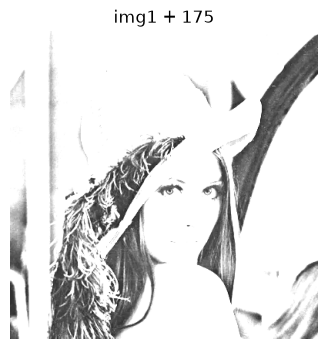

In [37]:
# Add a constant to img1, handling uint8 overflow correctly
constant = 175
added_constant = np.clip(im1arr.astype(np.int16) + constant, 0, 255).astype(np.uint8)

plt.figure(figsize=(4, 4))
plt.imshow(added_constant, cmap='gray')
plt.title(f'img1 + {constant}')
plt.axis('off')
plt.show()

---
## Part 3 — Sets and Logical Operations

Grayscale images can be combined the way sets are combined, by applying **bitwise operations** to their pixel values: `|` (OR) for union, `&` (AND) for intersection, `^` (XOR) for symmetric difference, and `~` (NOT) for the complement. Set difference `A - B` is then `A` intersected with `NOT B`, i.e. `A & ~B`.

### Load and display the two images

`A.png` and `B.png` are converted to grayscale (`'L'` mode) so the bitwise operations below act on a single channel.

In [38]:
import numpy as np
import cv2
import os

# التأكد من وجود مجلد الصور
os.makedirs('../images', exist_ok=True)

# إنشاء صورة A (مربع أبيض على خلفية سوداء)
imgA = np.zeros((400, 400), dtype=np.uint8)
cv2.rectangle(imgA, (100, 100), (300, 300), 255, -1)
cv2.imwrite('../images/A.png', imgA)

# إنشاء صورة B (دائرة بيضاء على خلفية سوداء متداخلة مع المربع)
imgB = np.zeros((400, 400), dtype=np.uint8)
cv2.circle(imgB, (250, 250), 120, 255, -1)
cv2.imwrite('../images/B.png', imgB)

print("تم إنشاء الصور A.png و B.png بنجاح!")

تم إنشاء الصور A.png و B.png بنجاح!


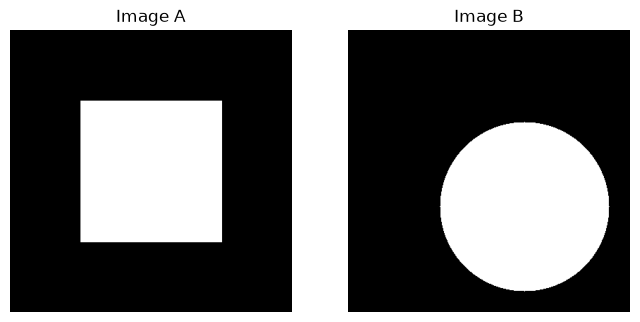

In [39]:
img3 = Image.open('../images/A.png').convert('L')
img4 = Image.open('../images/B.png').convert('L')

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(img3, cmap='gray')
plt.title('Image A')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(img4, cmap='gray')
plt.title('Image B')
plt.axis('off')
plt.show()

### Resize, convert to arrays, and take the union

Both images are resized to `400 x 400` (as in Part 2) so their arrays match element-for-element, exactly as the manual demonstrates for the union operation.

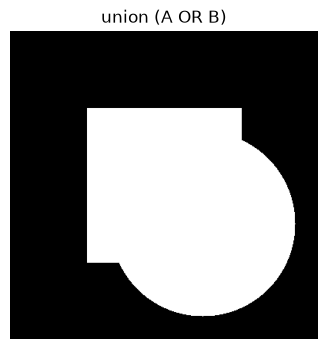

In [40]:
resize = (400, 400)
img3 = img3.resize(resize, Image.Resampling.LANCZOS)
img4 = img4.resize(resize, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

union = im4arr | im3arr  # A OR B, exactly as given in the manual

plt.figure(figsize=(4, 4))
plt.imshow(union, cmap='gray')
plt.title('union (A OR B)')
plt.axis('off')
plt.show()

---
### Task #2 (continued) — Set difference, symmetric difference, and intersection

Using the same bitwise convention as the union above.

**3. Set difference (A AND NOT B)**

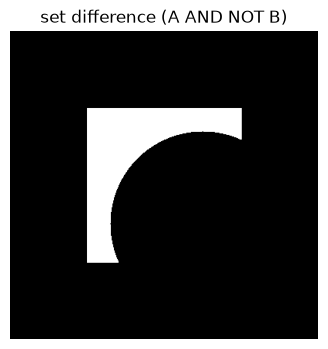

In [41]:
set_difference = im3arr & (~im4arr)  # A AND (NOT B)

plt.figure(figsize=(4, 4))
plt.imshow(set_difference, cmap='gray')
plt.title('set difference (A AND NOT B)')
plt.axis('off')
plt.show()

**4. Symmetric difference (A XOR B)**

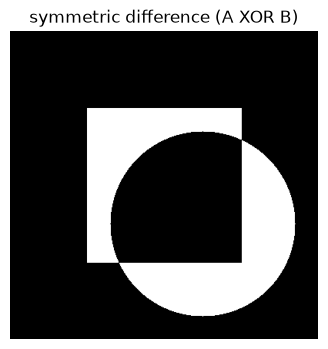

In [42]:
symmetric_difference = im3arr ^ im4arr  # A XOR B

plt.figure(figsize=(4, 4))
plt.imshow(symmetric_difference, cmap='gray')
plt.title('symmetric difference (A XOR B)')
plt.axis('off')
plt.show()

**5. Intersection (A AND B)**

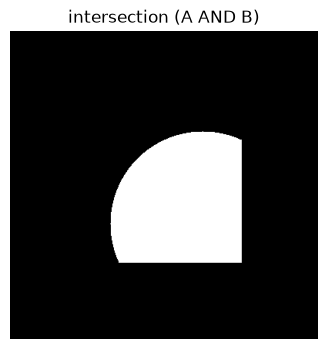

In [43]:
intersection = im3arr & im4arr  # A AND B

plt.figure(figsize=(4, 4))
plt.imshow(intersection, cmap='gray')
plt.title('intersection (A AND B)')
plt.axis('off')
plt.show()

**Observations:** the union keeps everything present in *either* image (brightest overall), the intersection keeps only what both images agree is bright (darkest/most restrictive), the set difference keeps what is bright in A while removing whatever is bright in B, and the symmetric difference highlights exactly the regions where A and B disagree.

---
---

# Assessment

As stated in the manual, the assessment for this lab is to accomplish Task #1 and Task #2 above within the lab session time — no additional operations are specified.

---

### Resources

* [OpenCV documentation](https://docs.opencv.org/3.4/da/d54/group__imgproc__transform.html)

**End of notebook.**